<a href="https://colab.research.google.com/github/Bhardwajsimran/mental-health/blob/main/Iris_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Preview
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  sepal_ratio  petal_ratio  sepal_area  petal_area  
0  setosa     1.457143          7.0       17.85        0.28  
1  setosa     1.633333          7.0       14.70        0.28  
2  setosa     1.468750          6.5       15.04        0.26  
3  setosa     1.483871          7.5       14.26        0.30  
4  setosa     1.388889          7.0       18.00        0.28  

Class Distribution
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


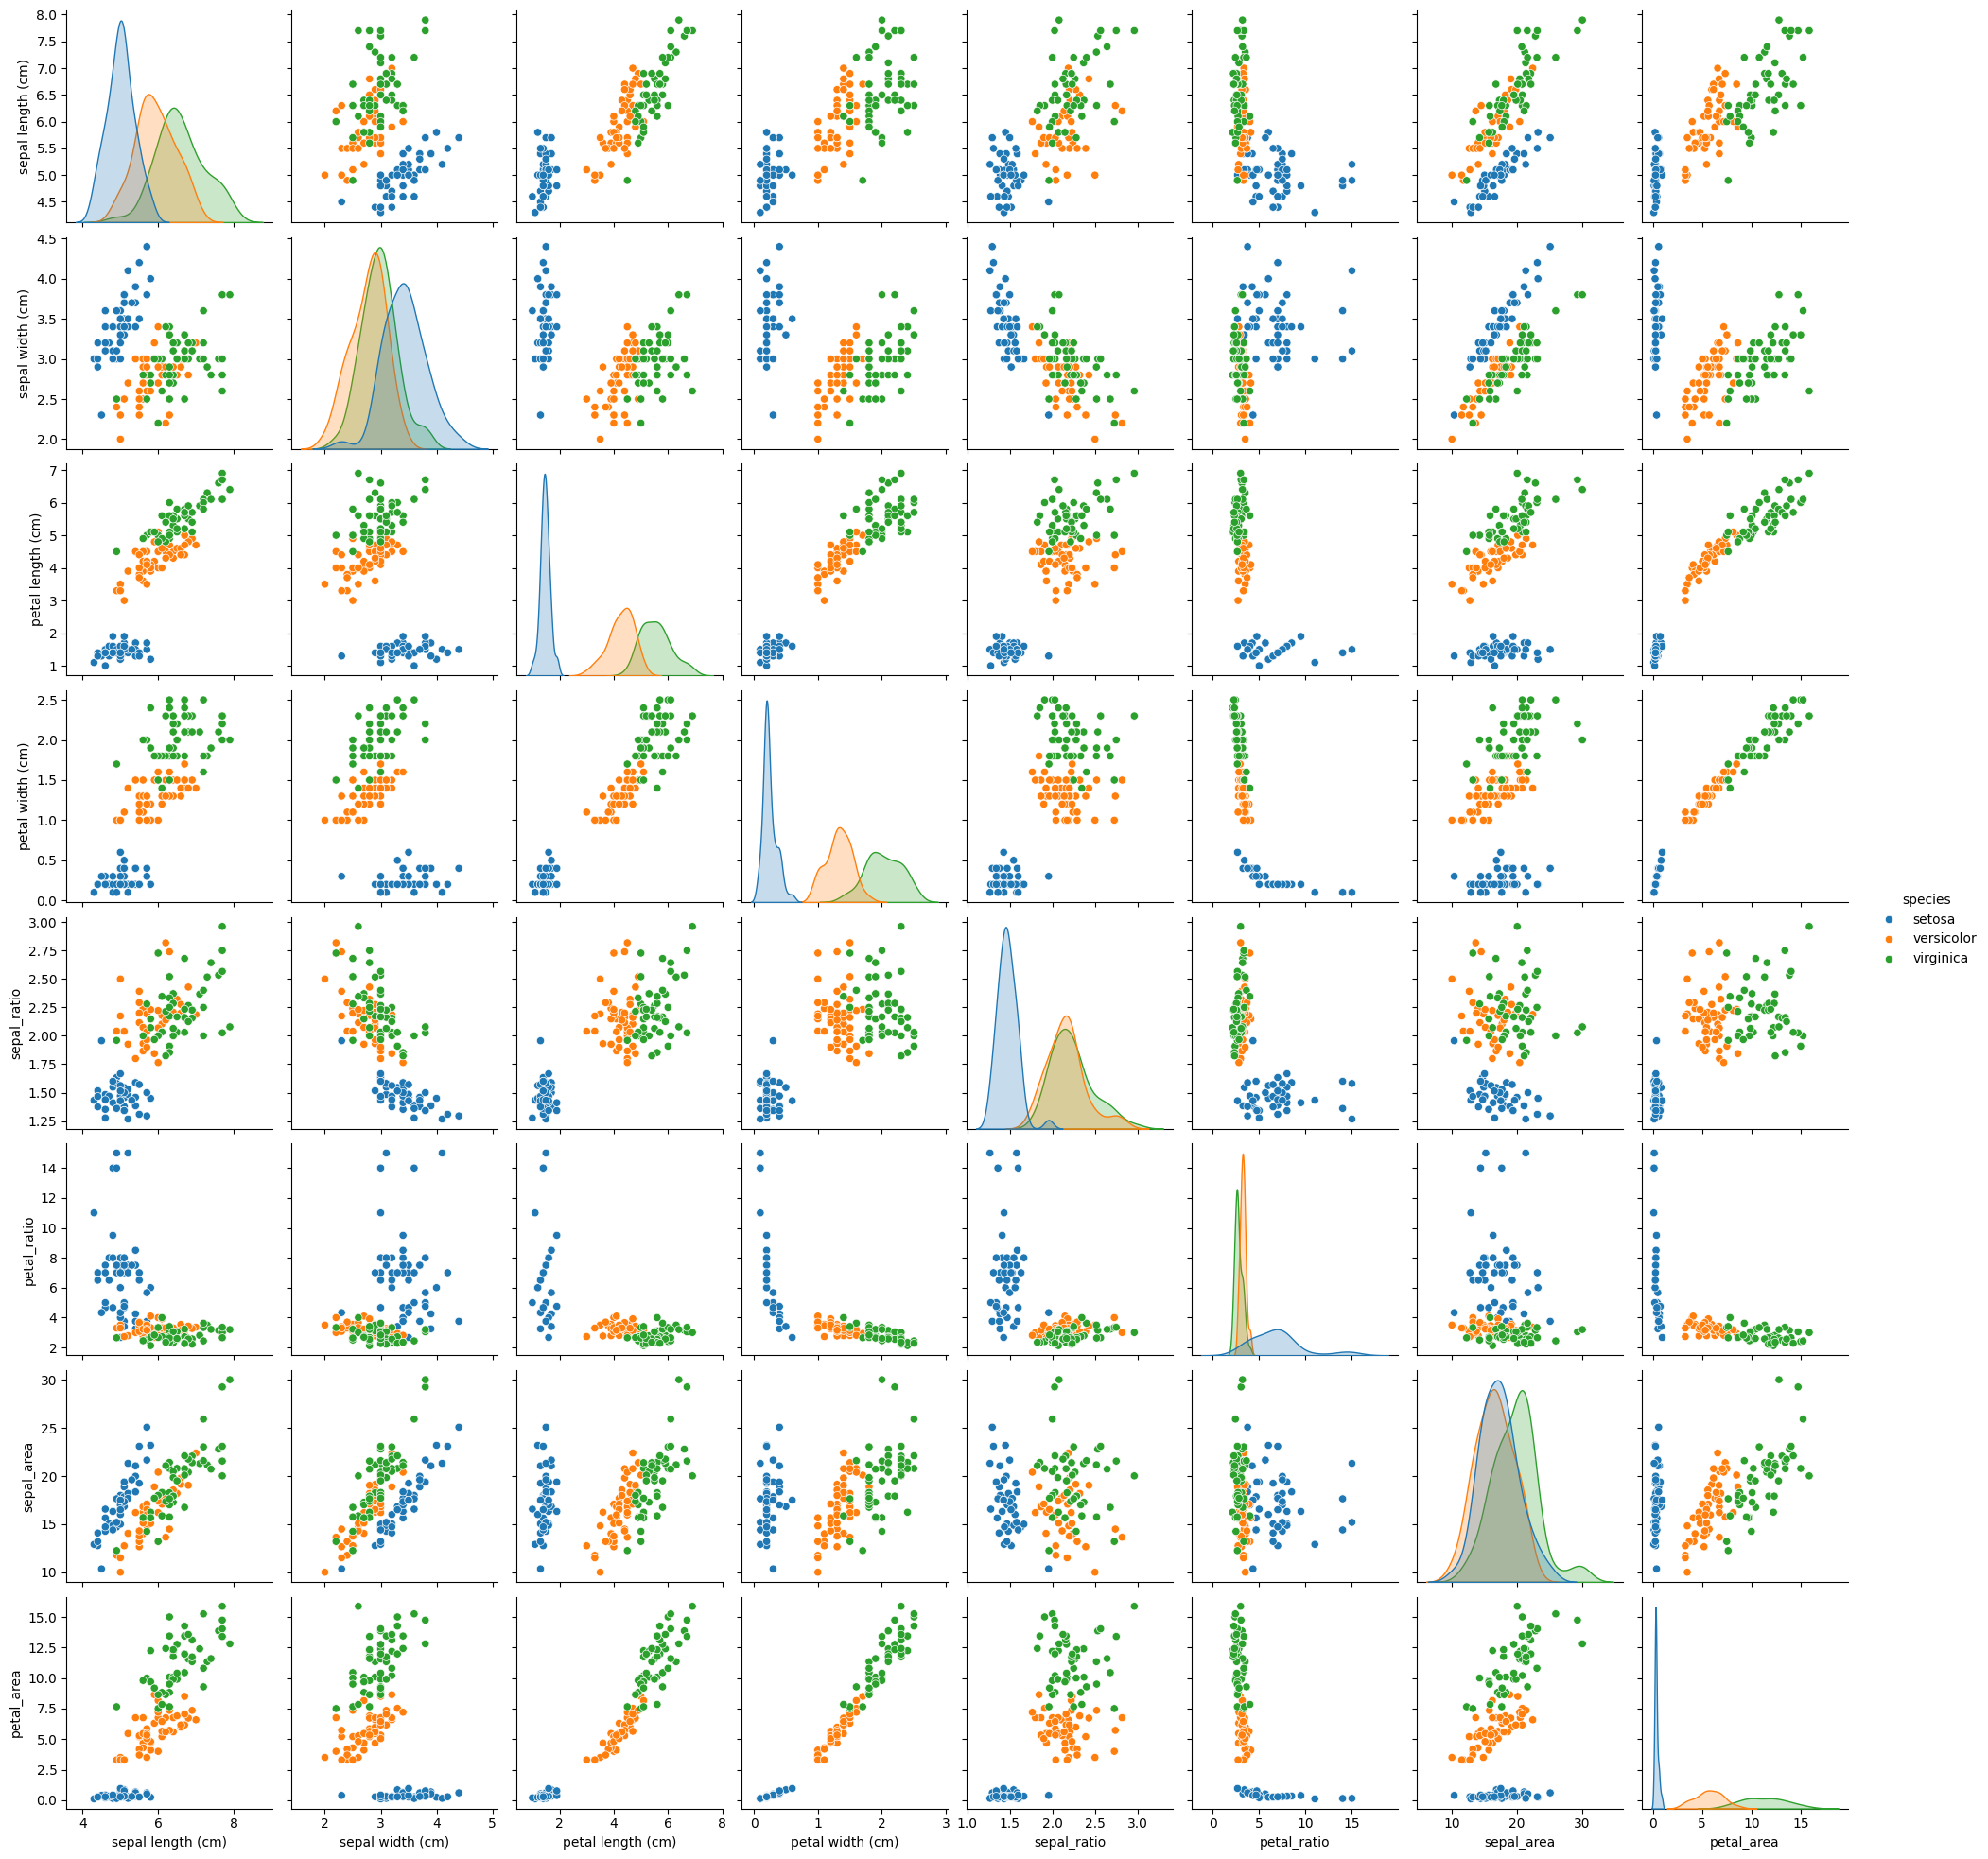

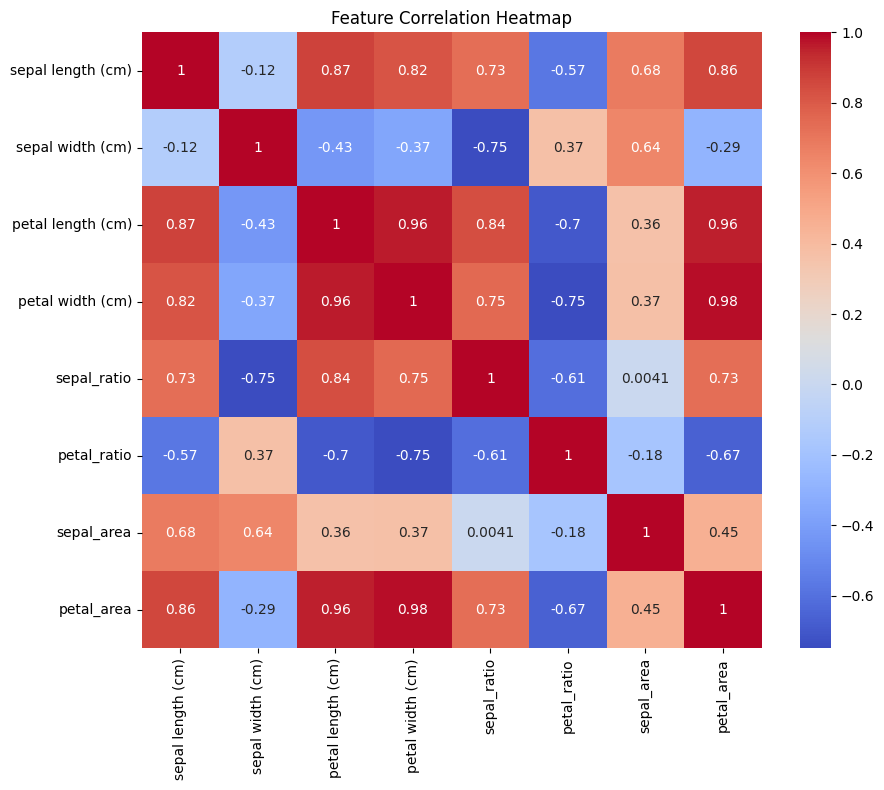


Logistic Regression
Accuracy: 0.9667

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



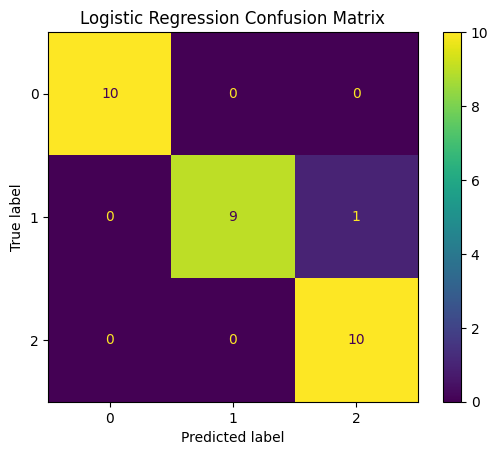


KNN
Accuracy: 0.9333

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



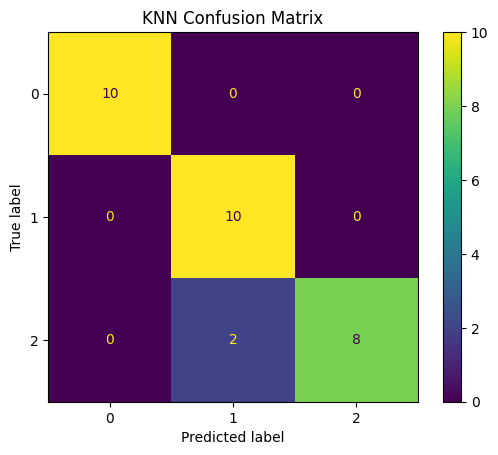


Decision Tree
Accuracy: 0.9000

Confusion Matrix
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



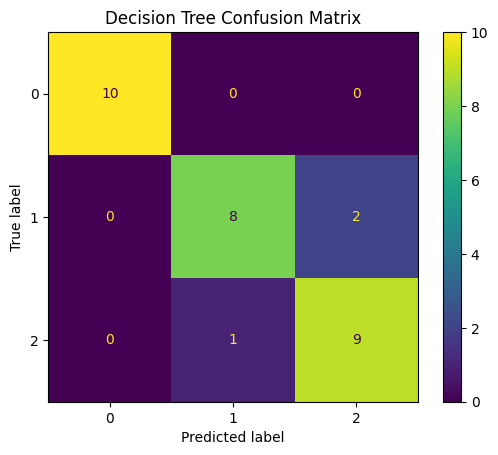


Random Forest
Accuracy: 0.9667

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



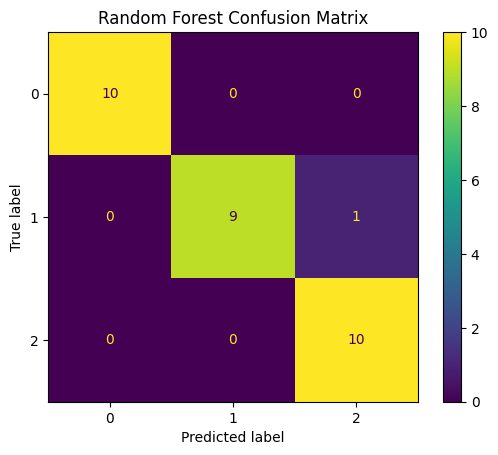


Gradient Boosting
Accuracy: 0.9000

Confusion Matrix
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



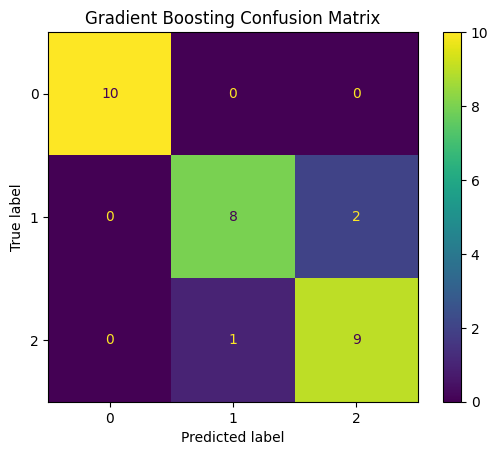



Cross Validation Scores
Logistic Regression: 0.9500
KNN: 0.9500
Decision Tree: 0.9500
Random Forest: 0.9500
Gradient Boosting: 0.9417

Accuracy Comparison
                 Model  Accuracy
0  Logistic Regression  0.966667
3        Random Forest  0.966667
1                  KNN  0.933333
2        Decision Tree  0.900000
4    Gradient Boosting  0.900000


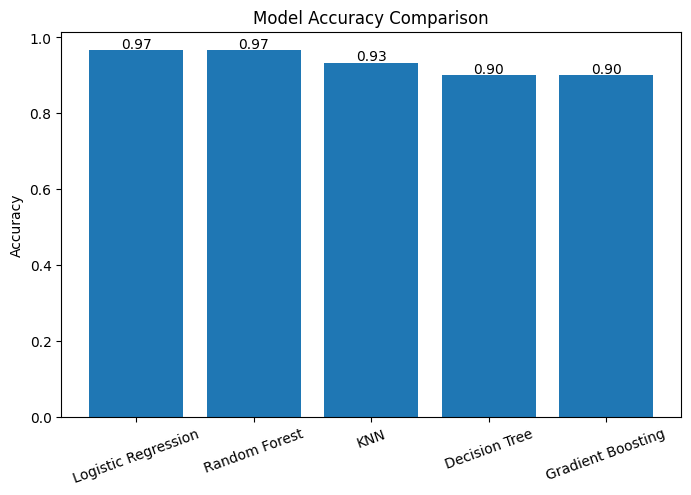



Best Model: Logistic Regression
Accuracy: 0.9667

Model Saved Successfully!

Predicted Species: setosa


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

# ==================================================
# LOAD DATASET
# ==================================================

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = pd.Series(
    iris.target
).map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# ==================================================
# FEATURE ENGINEERING
# ==================================================

df["sepal_ratio"] = (
    df["sepal length (cm)"]
    / df["sepal width (cm)"]
)

df["petal_ratio"] = (
    df["petal length (cm)"]
    / df["petal width (cm)"]
)

df["sepal_area"] = (
    df["sepal length (cm)"]
    * df["sepal width (cm)"]
)

df["petal_area"] = (
    df["petal length (cm)"]
    * df["petal width (cm)"]
)

# ==================================================
# DATA OVERVIEW
# ==================================================

print("\nDataset Preview")
print(df.head())

print("\nClass Distribution")
print(df["species"].value_counts())

# ==================================================
# PAIRPLOT
# ==================================================

sns.pairplot(
    df,
    hue="species"
)

plt.show()

# ==================================================
# CORRELATION HEATMAP
# ==================================================

numeric_df = df.drop(
    "species",
    axis=1
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# ==================================================
# SPLIT DATA
# ==================================================

X = df.drop(
    "species",
    axis=1
)

y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# FEATURE SCALING
# ==================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# ==================================================
# MODELS
# ==================================================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=200),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

# ==================================================
# TRAIN & EVALUATE
# ==================================================

results = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results[name] = accuracy

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print("\nConfusion Matrix")

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(cm)

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot()

    plt.title(
        f"{name} Confusion Matrix"
    )

    plt.show()

# ==================================================
# CROSS VALIDATION
# ==================================================

print("\n")
print("=" * 50)
print("Cross Validation Scores")
print("=" * 50)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f}"
    )

# ==================================================
# ACCURACY COMPARISON
# ==================================================

results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nAccuracy Comparison")
print(results_df)

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(rotation=20)

for i, value in enumerate(
    results_df["Accuracy"]
):
    plt.text(
        i,
        value + 0.005,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

# ==================================================
# BEST MODEL
# ==================================================

best_model_name = max(
    results,
    key=results.get
)

best_model = models[
    best_model_name
]

print("\n")
print("=" * 50)

print(
    f"Best Model: "
    f"{best_model_name}"
)

print(
    f"Accuracy: "
    f"{results[best_model_name]:.4f}"
)

# ==================================================
# FEATURE IMPORTANCE
# ==================================================

if best_model_name == "Random Forest":

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance":
        best_model.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\nFeature Importance")

    print(importance_df)

# ==================================================
# SAVE MODEL & SCALER
# ==================================================

joblib.dump(
    best_model,
    "iris_model.pkl"
)

joblib.dump(
    scaler,
    "iris_scaler.pkl"
)

print(
    "\nModel Saved Successfully!"
)

# ==================================================
# SAMPLE PREDICTION
# ==================================================

sl = 5.1
sw = 3.5
pl = 1.4
pw = 0.2

new_data = pd.DataFrame(
    [[
        sl,
        sw,
        pl,
        pw,
        sl/sw,
        pl/pw,
        sl*sw,
        pl*pw
    ]],
    columns=X.columns
)

prediction = best_model.predict(
    scaler.transform(new_data)
)

print(
    "\nPredicted Species:",
    prediction[0]
)